Missing values:
 f1        1
f2        1
f3        0
f4        1
f5        1
f6        1
f7        1
target    0
dtype: int64
Dataset statistics:
                f1          f2          f3          f4          f5          f6  \
count  765.000000  765.000000  766.000000  765.000000  765.000000  765.000000   
mean     3.849673  120.909804   69.118799   20.542484   80.091503   31.998170   
std      3.373696   31.947945   19.376901   15.960515  115.374383    7.898275   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.000000   62.500000    0.000000    0.000000   27.300000   
50%      3.000000  117.000000   72.000000   23.000000   36.000000   32.000000   
75%      6.000000  140.000000   80.000000   32.000000  128.000000   36.600000   
max     17.000000  199.000000  122.000000   99.000000  846.000000   67.100000   

               f7      target  
count  765.000000  766.000000  
mean     0.472128    0.349869  
std      0.331545    0.4772

/var/folders/q5/k500mm_91gjgv35442kd7g900000gn/T/ipykernel_1615/1091821164.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset[col].fillna(dataset[col].median(), inplace=True)
/var/folders/q5/k500mm_91gjgv35442kd7g900000gn/T/ipykernel_1615/1091821164.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

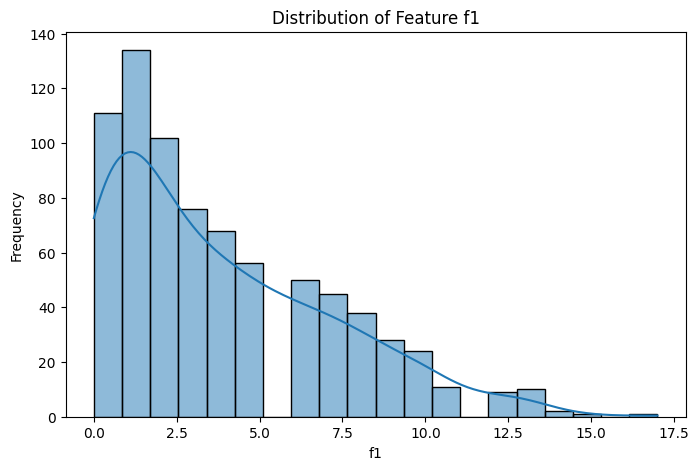

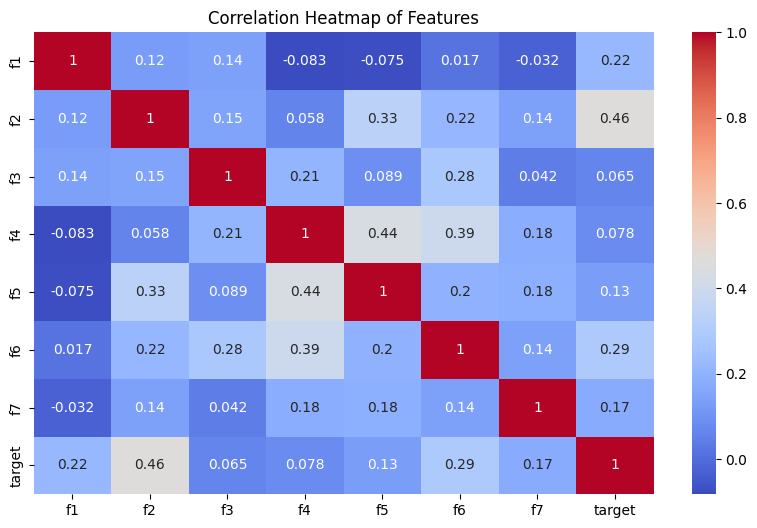

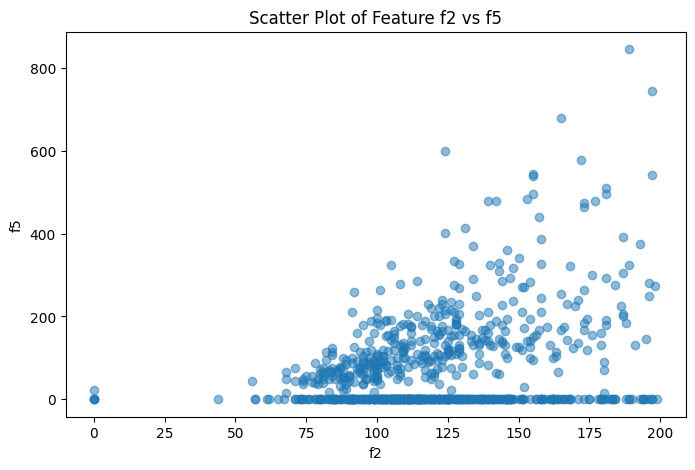

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '../data/dataset.csv'  
dataset = pd.read_csv(file_path)
for col in dataset.columns:
    if dataset[col].dtype == 'object':
        dataset[col] = pd.to_numeric(dataset[col], errors='coerce')
missing_values = dataset.isnull().sum()
print("Missing values:\n", missing_values)
dataset_statistics = dataset.describe()
print("Dataset statistics:\n", dataset_statistics)
for col in dataset.columns:
    dataset[col].fillna(dataset[col].median(), inplace=True)
print("Missing values after imputation:\n", dataset.isnull().sum())
plt.figure(figsize=(8, 5))
sns.histplot(dataset['f1'], kde=True, bins=20)
plt.title('Distribution of Feature f1')
plt.xlabel('f1')
plt.ylabel('Frequency')
plt.show()
plt.figure(figsize=(10, 6))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()
plt.figure(figsize=(8, 5))
plt.scatter(dataset['f2'], dataset['f5'], alpha=0.5)
plt.title('Scatter Plot of Feature f2 vs f5')
plt.xlabel('f2')
plt.ylabel('f5')
plt.show()


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
import torch
for col in dataset.columns:
    if dataset[col].dtype == 'object':
        dataset[col] = pd.to_numeric(dataset[col], errors='coerce')
for col in dataset.columns:
    dataset[col].fillna(dataset[col].median(), inplace=True)
X = dataset.drop('target', axis=1)
y = dataset['target']
categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    encoder = OneHotEncoder(drop='first', sparse_output=False)
    X_encoded = encoder.fit_transform(X[categorical_cols])
    X = X.drop(categorical_cols, axis=1)
    X = np.hstack((X, X_encoded))  
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_scaled, y)
X_resampled = pd.DataFrame(X_resampled)
y_resampled = pd.Series(y_resampled)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")
print(f"Test set size: {X_test.shape}")
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)
print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")

Training set size: (636, 7)
Validation set size: (160, 7)
Test set size: (200, 7)
X_train_tensor shape: torch.Size([636, 7])
y_train_tensor shape: torch.Size([636])


/var/folders/q5/k500mm_91gjgv35442kd7g900000gn/T/ipykernel_1615/1561482662.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset[col].fillna(dataset[col].median(), inplace=True)
/var/folders/q5/k500mm_91gjgv35442kd7g900000gn/T/ipykernel_1615/1561482662.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

1. Neural Network Architecture Design:
Input Neurons: The number of input neurons is equal to the number of features in the dataset.
Output Neurons: The number of output neurons depends on whether it's a binary or multi-class classification problem (typically 1 for binary classification).
Activation Functions: Common choices for hidden layers are ReLU or ELU. For binary classification, a Sigmoid function is often used in the output layer.
Hidden Layers: We’ll start with a simple architecture consisting of 3 hidden layers.
Size of Hidden Layers: We'll use 64 nodes for each hidden layer.
Dropout: To avoid overfitting, you can add Dropout layers.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class SimpleNN(nn.Module):
    def __init__(self, input_size, output_size, hidden_size=64, dropout_rate=0.5):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()  
        self.sigmoid = nn.Sigmoid()  
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.output(x)
        x = self.sigmoid(x)  
        return x
input_size = X_train_tensor.shape[1]  
output_size = 1  
model = SimpleNN(input_size, output_size)
print(model)
from torchinfo import summary
summary(model, input_size=(1, input_size)) 


SimpleNN(
  (fc1): Linear(in_features=7, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


Layer (type:depth-idx)                   Output Shape              Param #
SimpleNN                                 [1, 1]                    --
├─Linear: 1-1                            [1, 64]                   512
├─ReLU: 1-2                              [1, 64]                   --
├─Linear: 1-3                            [1, 64]                   4,160
├─ReLU: 1-4                              [1, 64]                   --
├─Linear: 1-5                            [1, 64]                   4,160
├─ReLU: 1-6                              [1, 64]                   --
├─Dropout: 1-7                           [1, 64]                   --
├─Linear: 1-8                            [1, 1]                    65
├─Sigmoid: 1-9                           [1, 1]                    --
Total params: 8,897
Trainable params: 8,897
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 

Epoch 1/50, Train Loss: 0.6783, Train Acc: 0.6132, Val Loss: 0.6493, Val Acc: 0.7562
Epoch 2/50, Train Loss: 0.6228, Train Acc: 0.7406, Val Loss: 0.5674, Val Acc: 0.7562
Epoch 3/50, Train Loss: 0.5615, Train Acc: 0.7311, Val Loss: 0.5012, Val Acc: 0.7562
Epoch 4/50, Train Loss: 0.5291, Train Acc: 0.7390, Val Loss: 0.4751, Val Acc: 0.7812
Epoch 5/50, Train Loss: 0.5216, Train Acc: 0.7563, Val Loss: 0.4720, Val Acc: 0.7875
Epoch 6/50, Train Loss: 0.5210, Train Acc: 0.7469, Val Loss: 0.4773, Val Acc: 0.7875
Epoch 7/50, Train Loss: 0.5145, Train Acc: 0.7516, Val Loss: 0.4748, Val Acc: 0.7937
Epoch 8/50, Train Loss: 0.5078, Train Acc: 0.7547, Val Loss: 0.4716, Val Acc: 0.8000
Epoch 9/50, Train Loss: 0.5017, Train Acc: 0.7689, Val Loss: 0.4709, Val Acc: 0.8063
Epoch 10/50, Train Loss: 0.5009, Train Acc: 0.7579, Val Loss: 0.4666, Val Acc: 0.8063
Epoch 11/50, Train Loss: 0.4941, Train Acc: 0.7626, Val Loss: 0.4691, Val Acc: 0.8000
Epoch 12/50, Train Loss: 0.4882, Train Acc: 0.7610, Val Loss: 0

/var/folders/q5/k500mm_91gjgv35442kd7g900000gn/T/ipykernel_1615/217057205.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('sreedivy_mee

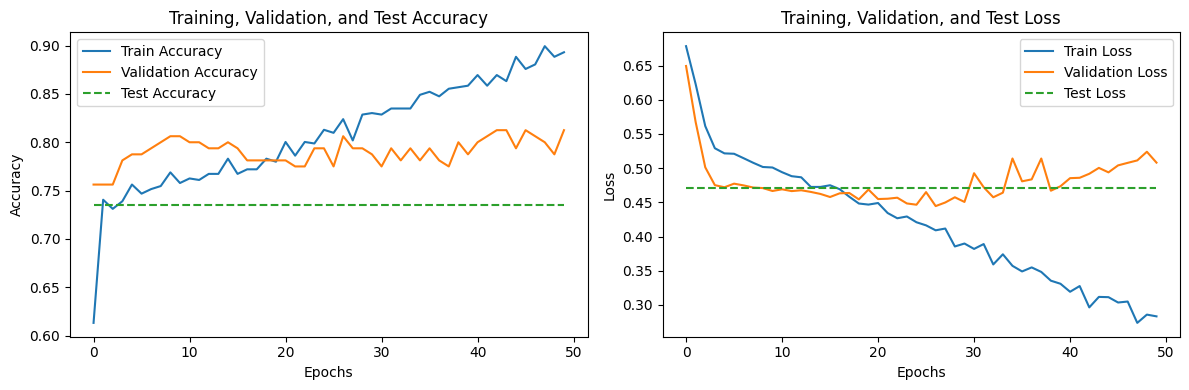

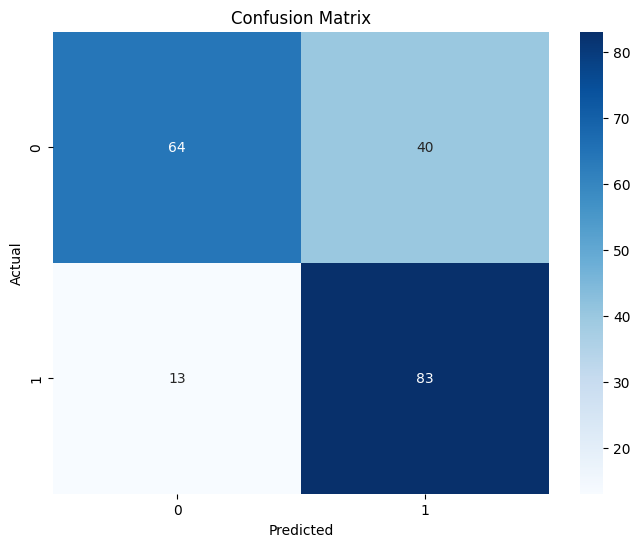

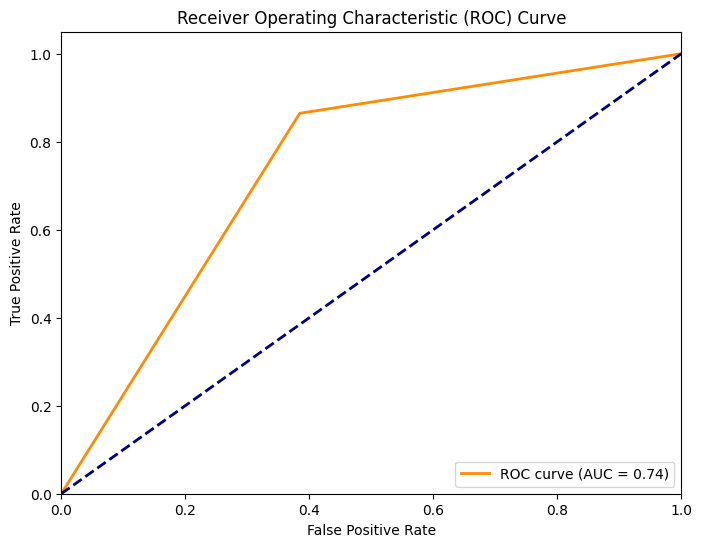

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)
loss_function = nn.BCELoss()
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
num_epochs = 50
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
best_val_loss = float('inf')
start_time = time.time()
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for inputs, labels in train_loader:
        outputs = model(inputs)
        outputs = outputs.squeeze(1)
        loss = loss_function(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        predicted = torch.round(outputs)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_outputs = model(val_inputs)
            val_outputs = val_outputs.squeeze(1)
            val_loss += loss_function(val_outputs, val_labels).item()
            val_predicted = torch.round(val_outputs)
            val_total += val_labels.size(0)
            val_correct += (val_predicted == val_labels).sum().item()
    val_loss /= len(val_loader)
    val_accuracy = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}')
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'part1_model.pt')
end_time = time.time()
training_time = end_time - start_time
print(f'Training time: {training_time:.2f} seconds')
model.load_state_dict(torch.load('part1_model.pt'))
model.eval()
test_loss = 0.0
test_correct = 0
test_total = 0
test_predictions = []
test_true_labels = []
with torch.no_grad():
    for test_inputs, test_labels in test_loader:
        test_outputs = model(test_inputs)
        test_outputs = test_outputs.squeeze(1)
        test_loss += loss_function(test_outputs, test_labels).item()
        test_predicted = torch.round(test_outputs)
        test_total += test_labels.size(0)
        test_correct += (test_predicted == test_labels).sum().item()
        test_predictions.extend(test_predicted.cpu().numpy())
        test_true_labels.extend(test_labels.cpu().numpy())
test_loss /= len(test_loader)
test_accuracy = test_correct / test_total
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')
precision, recall, f1_score, _ = precision_recall_fscore_support(test_true_labels, test_predictions, average='binary')
print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1_score:.4f}')
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.plot([test_accuracy] * num_epochs, label='Test Accuracy', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training, Validation, and Test Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.plot([test_loss] * num_epochs, label='Test Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training, Validation, and Test Loss')
plt.legend()
plt.tight_layout()
plt.show()
cm = confusion_matrix(test_true_labels, test_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
fpr, tpr, _ = roc_curve(test_true_labels, test_predictions)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()